# 02 – Continuum Basics in RelTrans

## What is the Continuum?

In X-ray astrophysics, the **continuum** represents the primary coronal emission 
that illuminates the accretion disk around a black hole.

In RelTrans, this continuum:

- Acts as the illuminating source for disk reflection  
- Determines the ionisation state of the disk  
- Controls the overall spectral shape  
- Strongly influences reverberation signatures  

Before modeling reflection and time lags, it is essential to understand 
the structure of the illuminating continuum itself.

---

## Focus of This Notebook

In this tutorial, we focus **only on the fundamental continuum parameters**, namely:

### Photon Index (Gamma)  
The photon index Γ controls the slope of the power-law continuum spectrum.  
Larger Γ produces a softer spectrum, while smaller Γ produces a harder spectrum.

### High-Energy Cutoff  
The high-energy cutoff represents the coronal electron temperature that limits photon energies.  
It introduces an exponential suppression of the spectrum at high energies.

### Energy Grid Construction  
The energy grid defines the discrete energy bins over which the spectrum is computed.  
Accurate grid construction is essential for stable numerical integration and flux normalization.

### Analytical Power-Law Form (`getcont.f90`)  
The analytical continuum follows a power-law with exponential cutoff form.  
This provides the baseline illuminating spectrum before relativistic and reflection effects are applied.

---

We intentionally do **not** yet include:

- Relativistic effects  
- Multiple lamp-post geometries  
- Reflection spectrum  
- Reverberation lags  

This notebook isolates the continuum to build strong physical intuition 
before moving to full RelTrans model evaluations.


import os
import numpy as np
import matplotlib.pyplot as plt
from ctypes import CDLL



### Inputs

- `Cp` → selects continuum type  
    - `Cp = 2` → use **nthComp Comptonization model**
    - otherwise → use **analytical cutoff power-law**
- `earx(0:nex)` → energy grid (keV)
- `nex` → number of grid bins
- `Gamma` → photon index
- `Cutoff` → high-energy cutoff (or electron temperature kTe)
- `logxi` → ionisation parameter
- `logne` → disk density

### Output

- `contx(nex)` → continuum spectrum

---

## Two Possible Branches

### Branch 1 — Physical Comptonization (Cp = 2)

RelTrans calls:




This computes a physically motivated Comptonization spectrum.

After that, the spectrum is renormalized to match the illuminating flux assumed in xillver.

---

### Branch 2 — Analytical Cutoff Power Law

If `Cp ≠ 2`, the continuum is constructed analytically:

\[
F(E) = E^{-\Gamma + 1} \exp(-E / Cutoff)
\]

This is a power-law with exponential cutoff.

This branch is simpler and ideal for educational exploration.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ctypes import CDLL

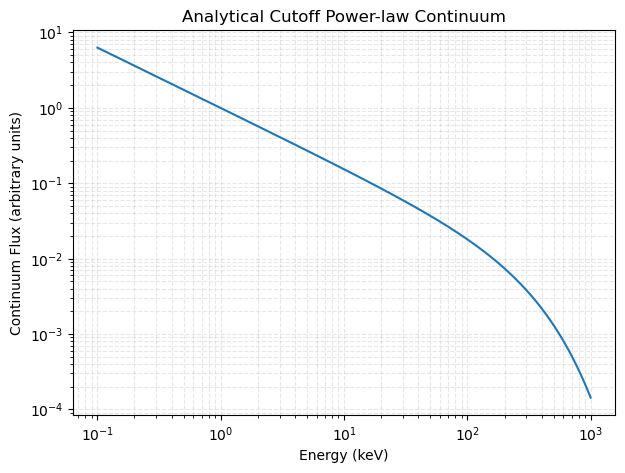

In [4]:
# Energy grid (similar logic to reltrans internal grids)
Emin = 0.1
Emax = 1000.0
nex = 2000

earx = np.logspace(np.log10(Emin), np.log10(Emax), nex + 1)

# Mid-bin energies (like Fortran code uses)
E = 0.5 * (earx[1:] + earx[:-1])

# Parameters
Gamma = 1.8
Cutoff = 300.0  # keV

# Analytical cutoff power-law branch from getcont.f90
cont = E**(-Gamma + 1) * np.exp(-E / Cutoff)

plt.figure(figsize=(7,5))
plt.loglog(E, cont)
plt.xlabel("Energy (keV)")
plt.ylabel("Continuum Flux (arbitrary units)")
plt.title("Analytical Cutoff Power-law Continuum")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()


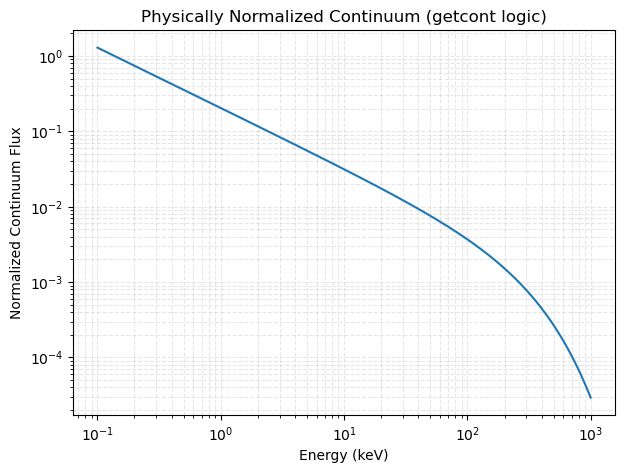

In [5]:
# Physical parameters
logxi = 3.0
logne = 15.0

pi = np.pi
ergsev = 1.602197e-9  # keV to erg conversion

# Compute Icomp (integrated flux in 0.1–1000 keV)
mask = (E >= 0.1) & (E <= 1e3)
Icomp = np.sum(E[mask] * cont[mask])

# Incident flux
inc_flux = 10**(logne + logxi) / (4.0 * pi) / ergsev

# Normalization factor
norm = inc_flux / Icomp / 1e20

# Apply normalization
cont_norm = cont * norm / (10**(logxi + logne - 15))

plt.figure(figsize=(7,5))
plt.loglog(E, cont_norm)
plt.xlabel("Energy (keV)")
plt.ylabel("Normalized Continuum Flux")
plt.title("Physically Normalized Continuum (getcont logic)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()


## Interpretation of the Physically Normalized Continuum

In this step, we reproduced the normalization logic implemented in `getcont.f90`.

Although the **spectral shape** remains a cutoff power-law,

\[
F(E) \propto E^{-\Gamma + 1} \exp\left(-\frac{E}{E_{\mathrm{cut}}}\right),
\]

the **absolute flux level** is no longer arbitrary.

Instead, it is scaled according to the physically motivated illuminating flux:

\[
F_{\mathrm{inc}} = \frac{10^{(\log n_e + \log \xi)}}{4\pi \, (1.602197 \times 10^{-9})}
\]

where:

- $\log \xi$ is the ionisation parameter  
- $\log n_e$ is the electron density  

This normalization ensures that:

- The continuum used inside **RelTrans**
- The illuminating flux assumed in **xillver**
- And the reflection spectrum normalization  

are all internally consistent.

This is a crucial physical step — RelTrans does not use an arbitrary continuum normalization.  
It enforces flux consistency between the illuminating source and the reflection model.
